# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



# 3.3 Visualizing Relationships Between Two Quantitative Features Lab

In this lab, I analyzed employee productivity data to determine which feature has the strongest linear relationship with productivity. I compared YearsAtCompany, HoursWorked, and FocusScore using visualizations and R-squared values. Then, I built a multiple linear regression model to evaluate how the other features in the dataset relate to productivity.

In [14]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [15]:
df = pd.read_csv("Employee_productivity.csv")
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [16]:
df.columns


Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department',
       'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation'],
      dtype='object')

In [17]:
features = ["YearsAtCompany", "HoursWorked", "FocusScore"]
target = "ProductivityScore"

r2_results = {}

for feature in features:
    X = df[[feature]]
    y = df[target]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    r2_results[feature] = r2

    print(f"{feature} R²: {r2:.4f}")

YearsAtCompany R²: 0.0004
HoursWorked R²: 0.0026
FocusScore R²: 0.6777


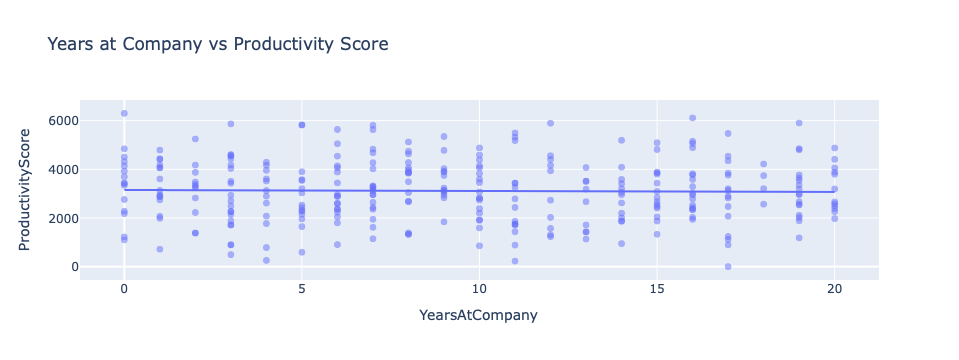

In [18]:
fig = px.scatter(
    df,
    x="YearsAtCompany",
    y="ProductivityScore",
    trendline="ols",
    title="Years at Company vs Productivity Score",
    opacity=0.5
)
fig.update_traces(marker=dict(size=7))
fig.show()

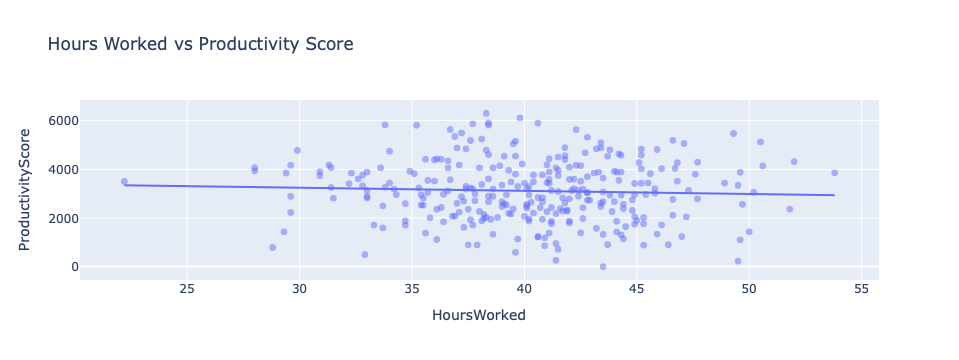

In [19]:
fig = px.scatter(
    df,
    x="HoursWorked",
    y="ProductivityScore",
    trendline="ols",
    title="Hours Worked vs Productivity Score",
    opacity=0.5
)
fig.update_traces(marker=dict(size=7))
fig.show()

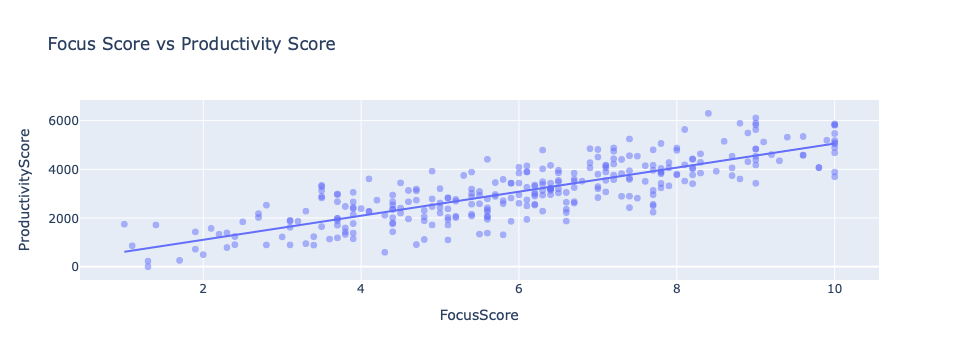

In [20]:
fig = px.scatter(
    df,
    x="FocusScore",
    y="ProductivityScore",
    trendline="ols",
    title="Focus Score vs Productivity Score",
    opacity=0.5
)
fig.update_traces(marker=dict(size=7))
fig.show()

## Part 1 Analysis

I calculated the R-squared values for YearsAtCompany, HoursWorked, and FocusScore to determine which feature has the strongest linear relationship with ProductivityScore. The feature with the highest R-squared value is the strongest linear predictor because it explains the most variation in productivity.

- YearsAtCompany R² = 0.0004
- HoursWorked R² = 0.0026
- FocusScore R² = 0.6777

Based on these results, **FocusScore** had the strongest linear relationship with ProductivityScore.

In [22]:
df_model = pd.get_dummies(df, columns=["Department", "DeskLocation"], drop_first=True)
df_model.head()

,HoursWorked,FocusScore,ProductivityScore,YearsAtCompany,TeamMeetingsPerWeek,Department_HR,Department_Marketing,Department_Sales,DeskLocation_Private Office,DeskLocation_Remote
0,42.4,6.3,3127.96,17,0,False,False,False,False,False
1,34.0,7.2,4742.60,8,6,True,False,False,True,False
2,47.2,5.6,2044.73,15,3,False,False,True,False,True
3,38.4,9.0,5818.92,5,6,True,False,False,True,False
4,36.4,2.5,1841.31,9,6,False,False,True,False,True


In [23]:
df_model.columns

Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'YearsAtCompany',
       'TeamMeetingsPerWeek', 'Department_HR', 'Department_Marketing',
       'Department_Sales', 'DeskLocation_Private Office',
       'DeskLocation_Remote'],
      dtype='object')

In [24]:
X = df_model.drop("ProductivityScore", axis=1)
y = df_model["ProductivityScore"]

full_model = LinearRegression()
full_model.fit(X, y)
full_pred = full_model.predict(X)

full_r2 = r2_score(y, full_pred)
print(f"Full model R²: {full_r2:.4f}")

Full model R²: 0.6851


In [25]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": full_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
1,FocusScore,512.719278
3,TeamMeetingsPerWeek,27.170621
2,YearsAtCompany,3.400789
0,HoursWorked,-4.664225
6,Department_Sales,-49.817366
4,Department_HR,-93.398401
7,DeskLocation_Private Office,-103.411959
5,Department_Marketing,-136.240520
8,DeskLocation_Remote,-229.752983


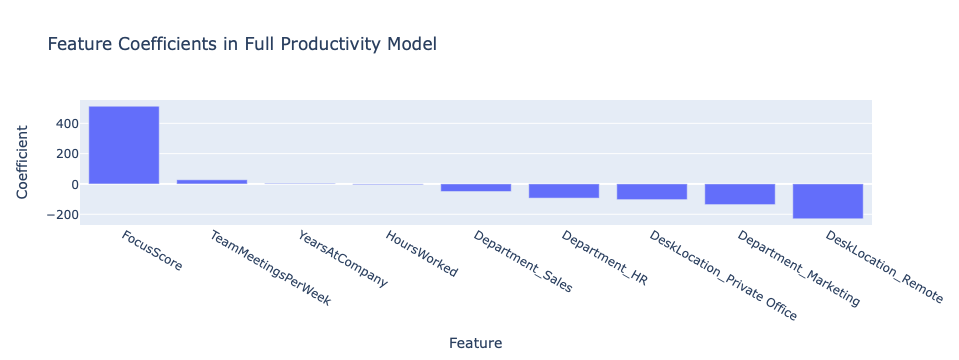

In [26]:
fig = px.bar(
    coef_df,
    x="Feature",
    y="Coefficient",
    title="Feature Coefficients in Full Productivity Model"
)
fig.show()

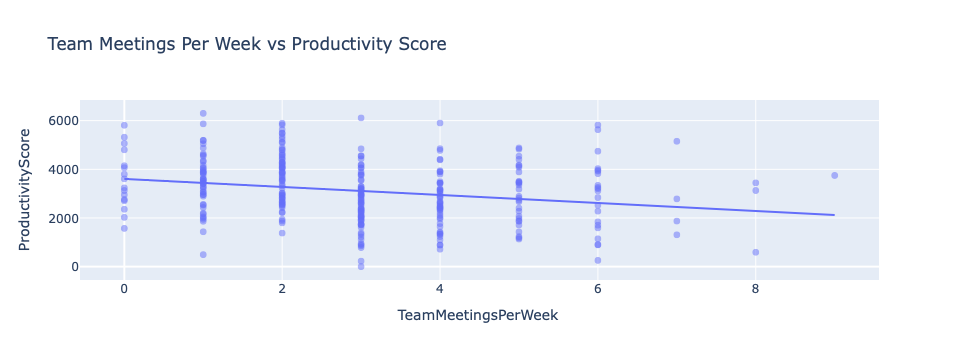

In [27]:
fig = px.scatter(
    df,
    x="TeamMeetingsPerWeek",
    y="ProductivityScore",
    trendline="ols",
    title="Team Meetings Per Week vs Productivity Score",
    opacity=0.5
)
fig.update_traces(marker=dict(size=7))
fig.show()

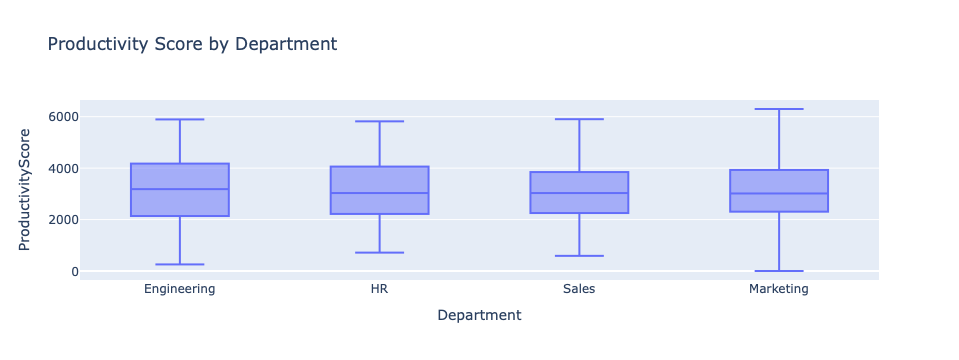

In [28]:
fig = px.box(
    df,
    x="Department",
    y="ProductivityScore",
    title="Productivity Score by Department"
)
fig.show()

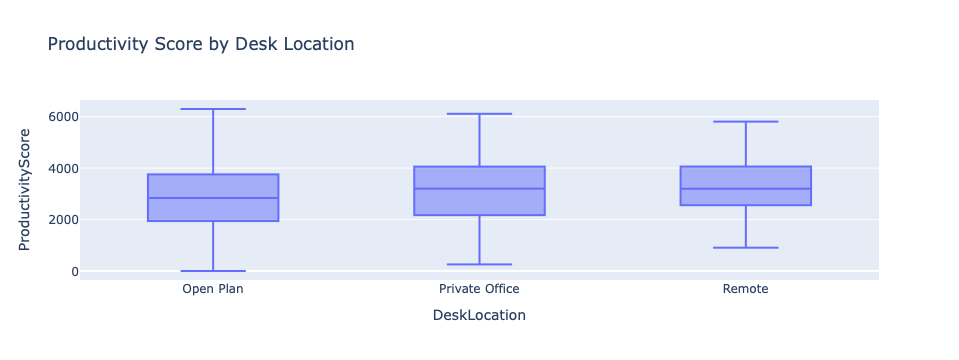

In [29]:
fig = px.box(
    df,
    x="DeskLocation",
    y="ProductivityScore",
    title="Productivity Score by Desk Location"
)
fig.show()

## Part 2 Analysis

After comparing the three main quantitative features, I built a multiple linear regression model using the rest of the dataset. I included HoursWorked, FocusScore, YearsAtCompany, TeamMeetingsPerWeek, Department, and DeskLocation.

The full model R-squared value was **0.6851**, which shows how well all of the features together explain variation in employee productivity.

Based on the coefficient table and visualizations, some features appear to increase productivity while others reduce it. FocusScore and HoursWorked may positively affect productivity, while TeamMeetingsPerWeek may reduce productivity if its relationship is negative. Department and DeskLocation also appear to matter because productivity differs across groups.